# OLSD Quickstart

This notebook demonstrates the core OLSD workflow:
1. Generate locomotion trajectories
2. Validate and compute gait metrics
3. Load, filter, and split datasets
4. Visualize trajectories and compare robots

In [1]:
import olsd
import numpy as np
print(f"OLSD version: {olsd.__version__}")

OLSD version: 0.1.0


## 1. Generate Trajectories

Generate 20 episodes using the HalfCheetah environment with a random policy.

In [2]:
from olsd.generation.mujoco_gen import generate_trajectories

episodes = generate_trajectories(
    robot_id="halfcheetah",
    n_episodes=20,
    max_steps=200,
    policy="random",
    seed=42,
)
print(f"Generated {len(episodes)} episodes, {sum(e.n_steps for e in episodes)} total steps")

Generated 20 episodes, 4000 total steps


## 2. Validate Episodes

In [3]:
from olsd.pipeline.validate import validate_dataset

results = validate_dataset(episodes)
n_valid = sum(1 for r in results if r.valid)
print(f"Validation: {n_valid}/{len(results)} episodes valid")

Validation: 20/20 episodes valid


## 3. Compute Gait Metrics

In [4]:
from olsd.pipeline.metrics import compute_metrics

m = compute_metrics(episodes[0])
print(f"Stride frequency:  {m.stride_frequency:.2f} Hz")
print(f"Energy per meter:  {m.energy_per_meter:.2f} J/m")
print(f"Smoothness index:  {m.smoothness_index:.4f}")
print(f"Mean power:        {m.mean_power_watts:.2f} W")
print(f"Duration:          {m.duration_seconds:.2f} s")

Stride frequency:  1.25 Hz
Energy per meter:  56.00 J/m
Smoothness index:  0.6453
Mean power:        3.41 W
Duration:          3.98 s


## 4. Export and Reload

In [5]:
from pathlib import Path
from olsd.pipeline.export import to_parquet

# Export
to_parquet(episodes, "./data/notebook_demo")

# Reload
dataset = olsd.load("./data/notebook_demo")

summary = dataset.summary()
for key, val in summary.items():
    print(f"{key}: {val}")

total_episodes: 20
total_steps: 4000
robots: ['halfcheetah']
morphologies: ['other']
terrains: ['flat']
sources: ['simulation']
success_rate: 1.0


## 5. Filter and Split

In [6]:
# Filter by robot
cheetahs = dataset.filter(robot_id="halfcheetah")
print(f"HalfCheetah episodes: {len(cheetahs)}")

# Train/Val/Test split
train, val, test = dataset.split(train=0.8, val=0.1, test=0.1)
print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

HalfCheetah episodes: 20
Train: 16, Val: 2, Test: 2


## 6. Visualize Trajectories

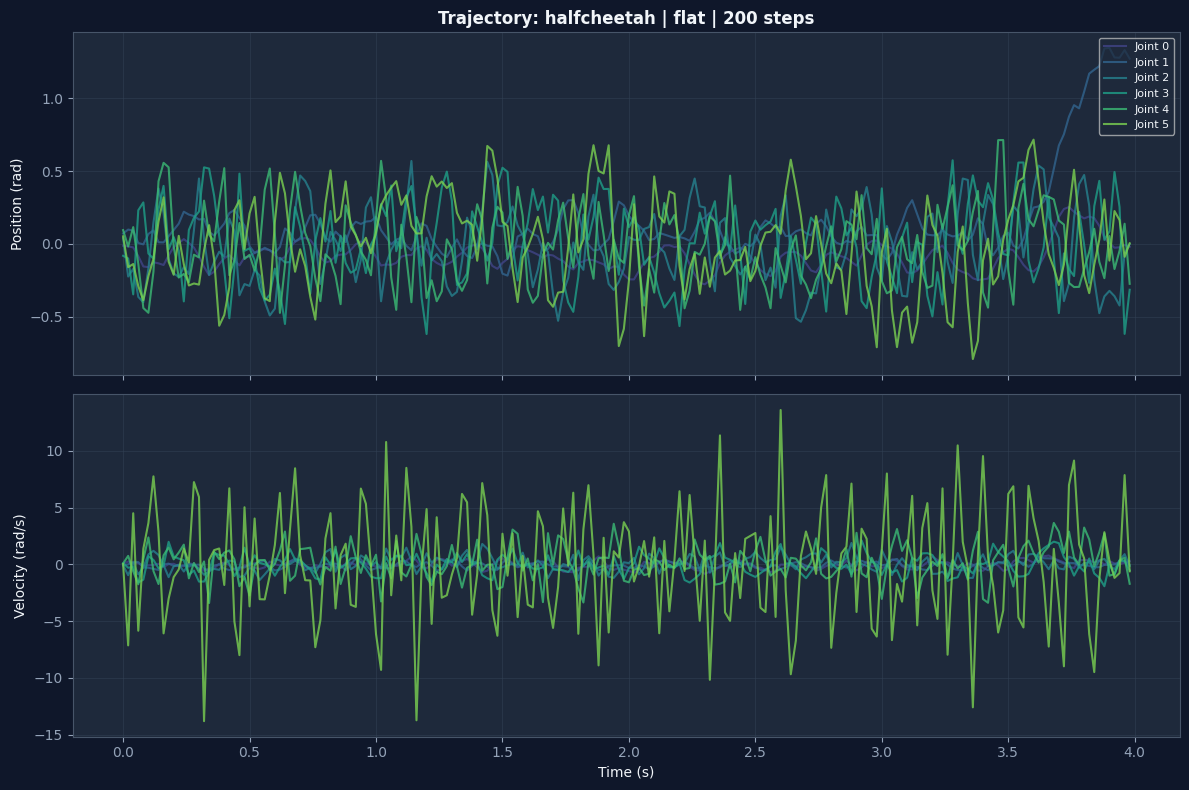

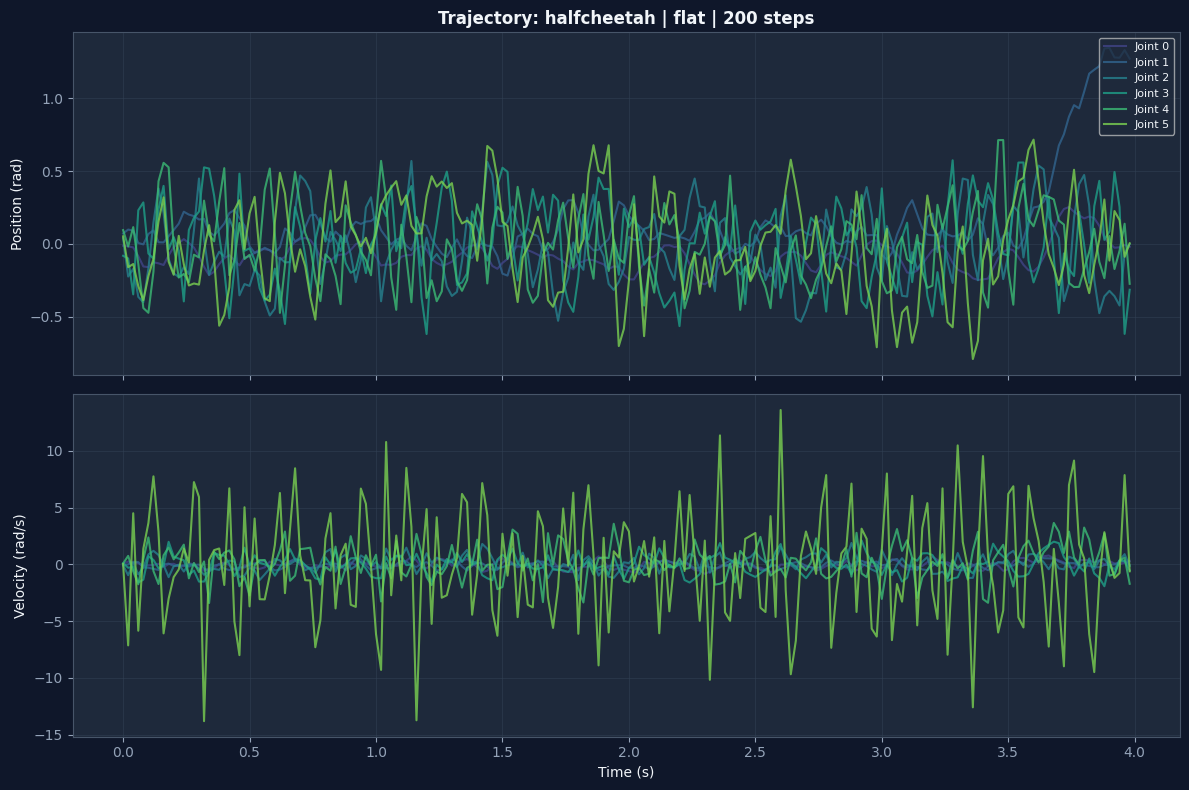

In [7]:
from olsd.sdk.visualization import plot_trajectory, plot_phase_portrait, plot_rewards

plot_trajectory(dataset[0], show=True)

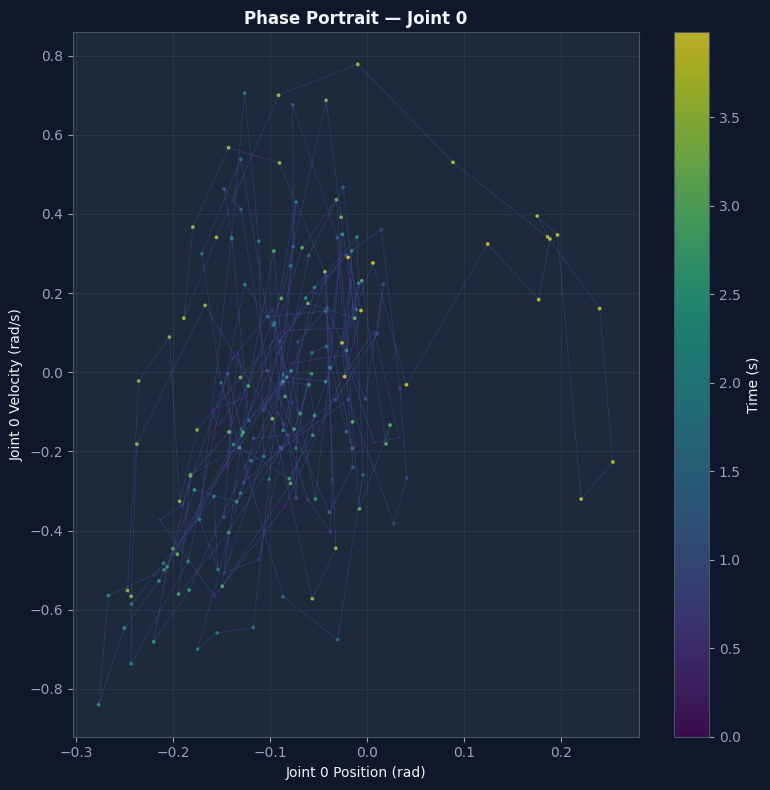

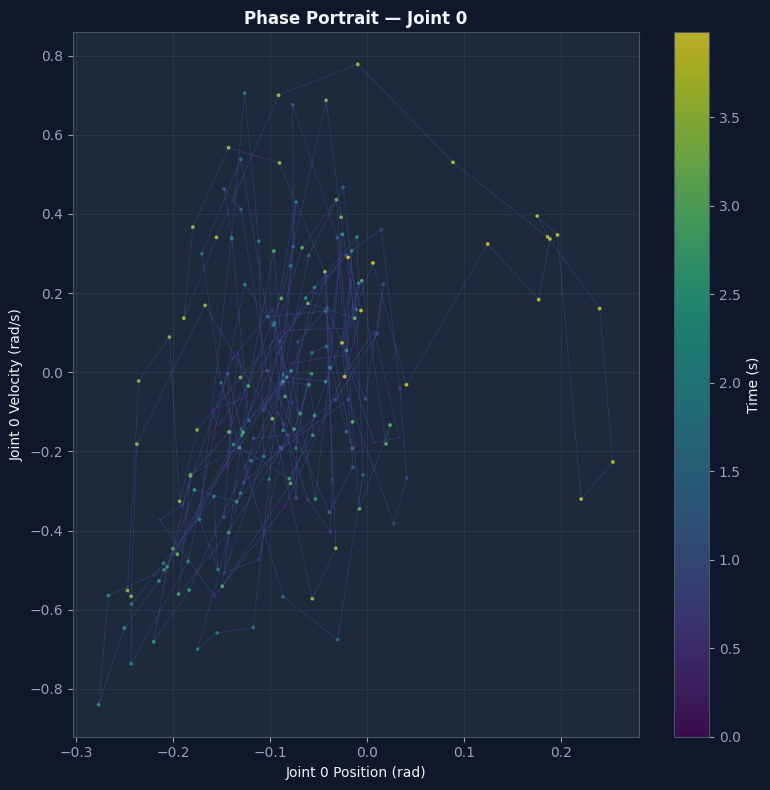

In [8]:
plot_phase_portrait(dataset[0], joint_idx=0, show=True)

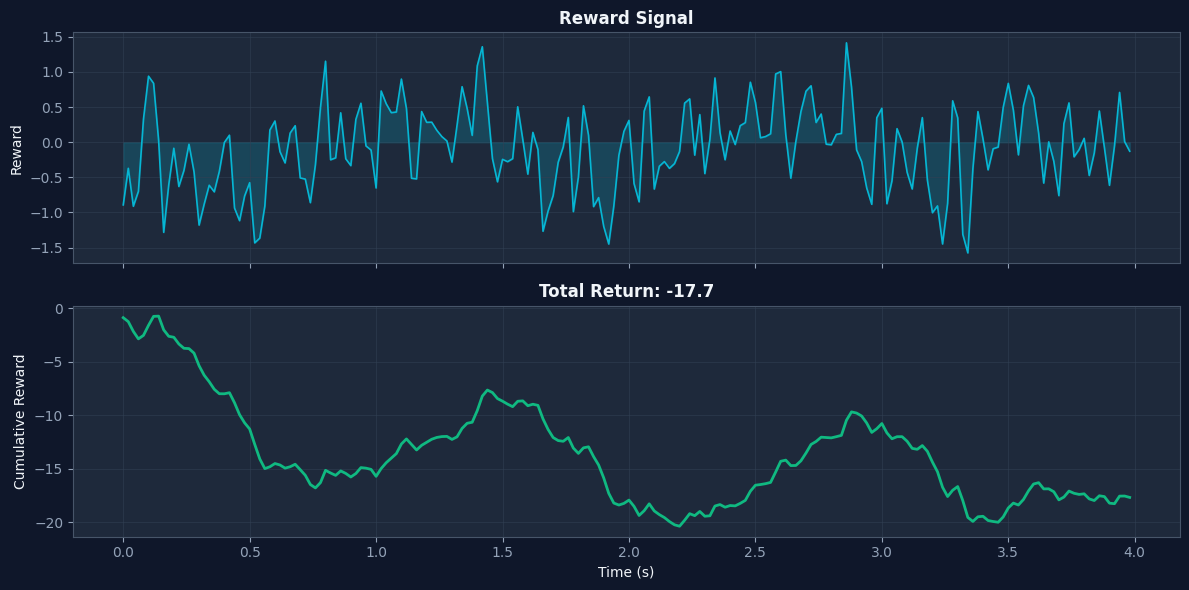

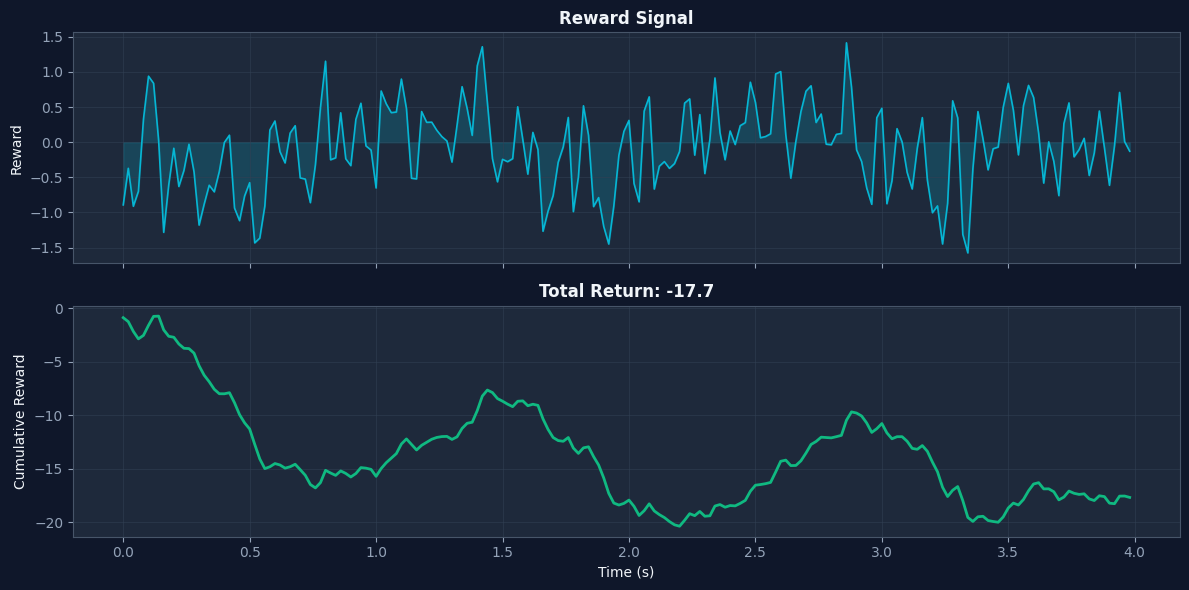

In [9]:
plot_rewards(dataset[0], show=True)

## 7. Dataset Overview (Multi-Robot)

Generate data for multiple robots and compare.

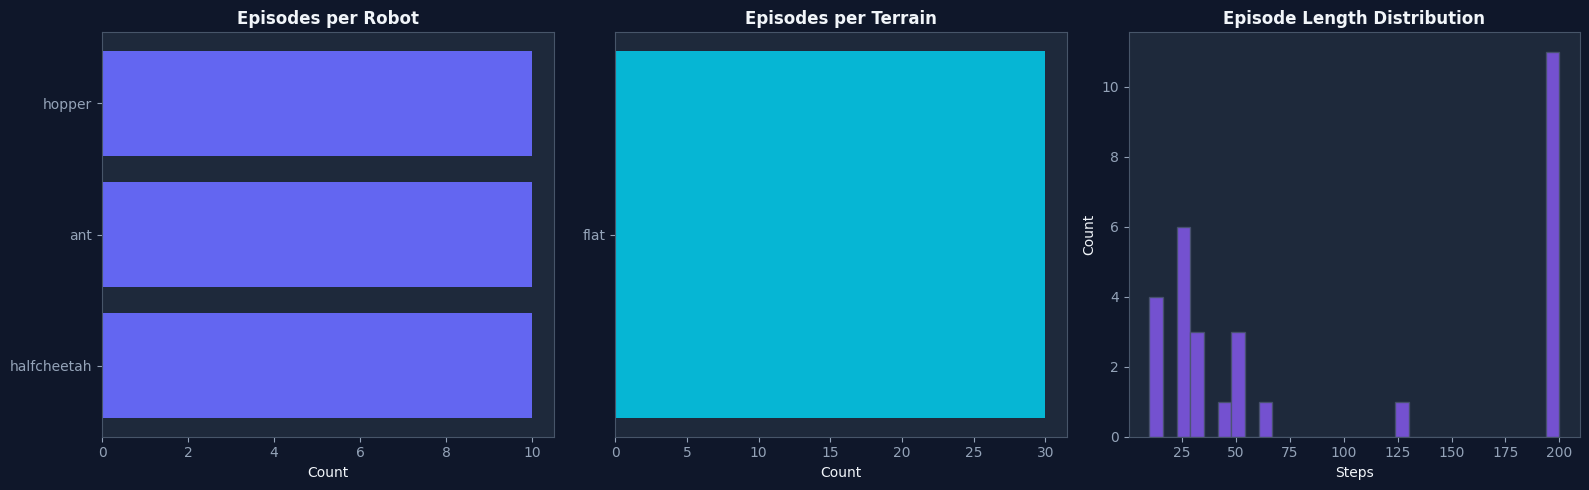

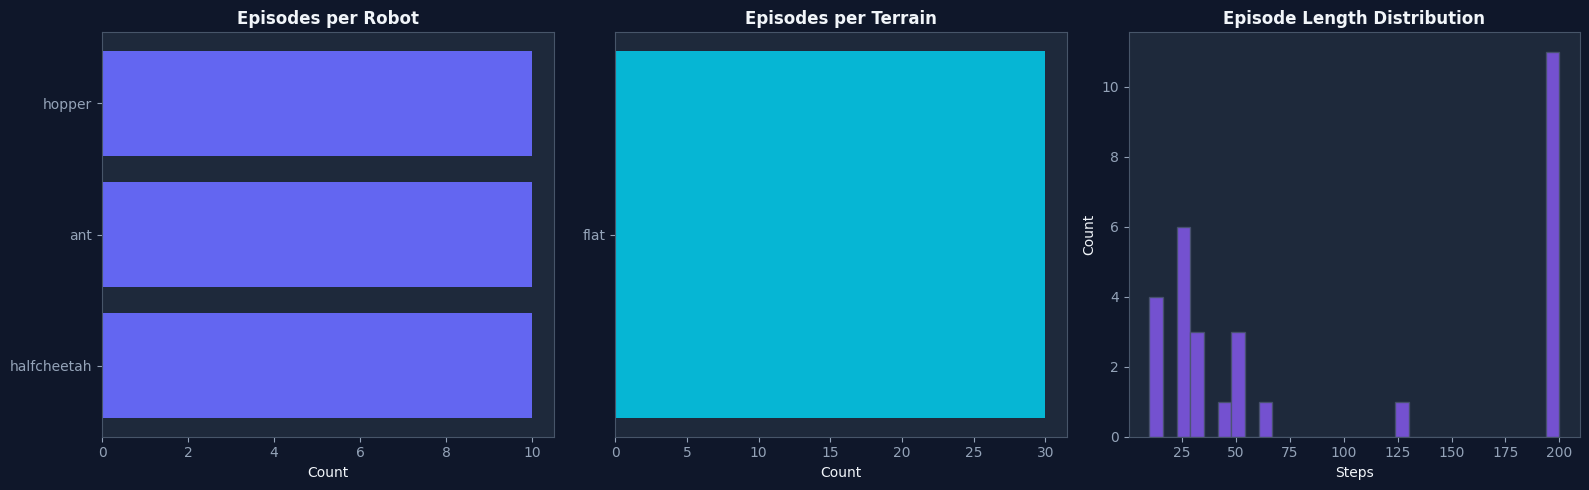

In [10]:
all_eps = []
for robot in ["halfcheetah", "ant", "hopper"]:
    eps = generate_trajectories(robot, n_episodes=10, max_steps=200, seed=42)
    all_eps.extend(eps)

from olsd.sdk.visualization import plot_dataset_overview
plot_dataset_overview(all_eps, show=True)

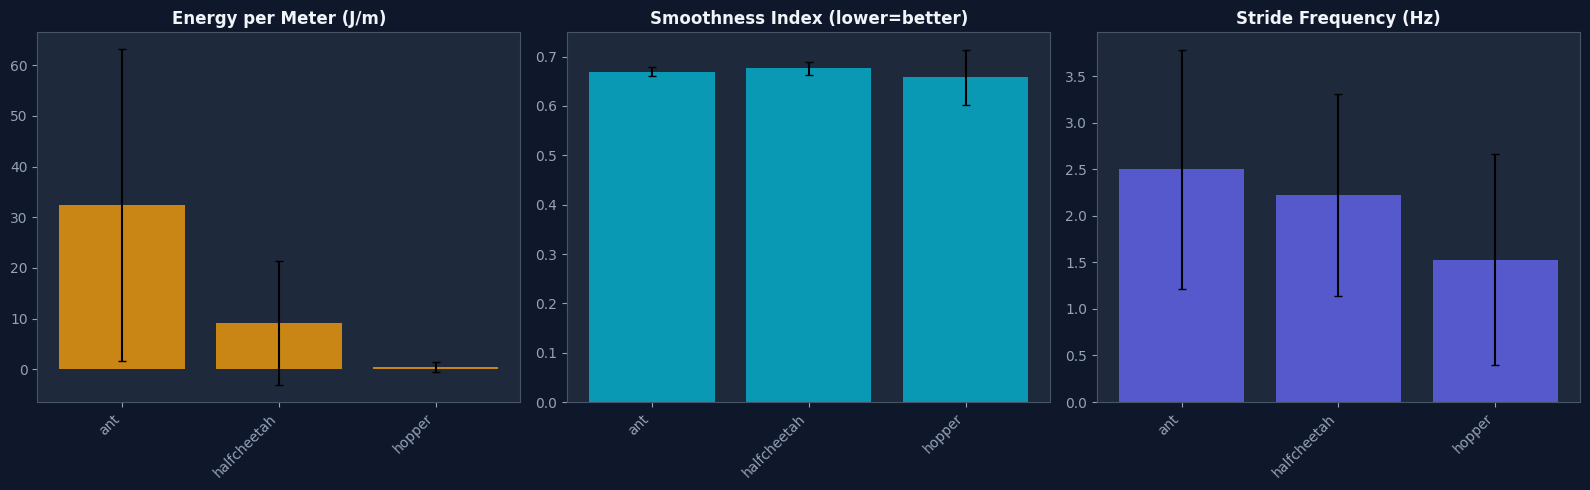

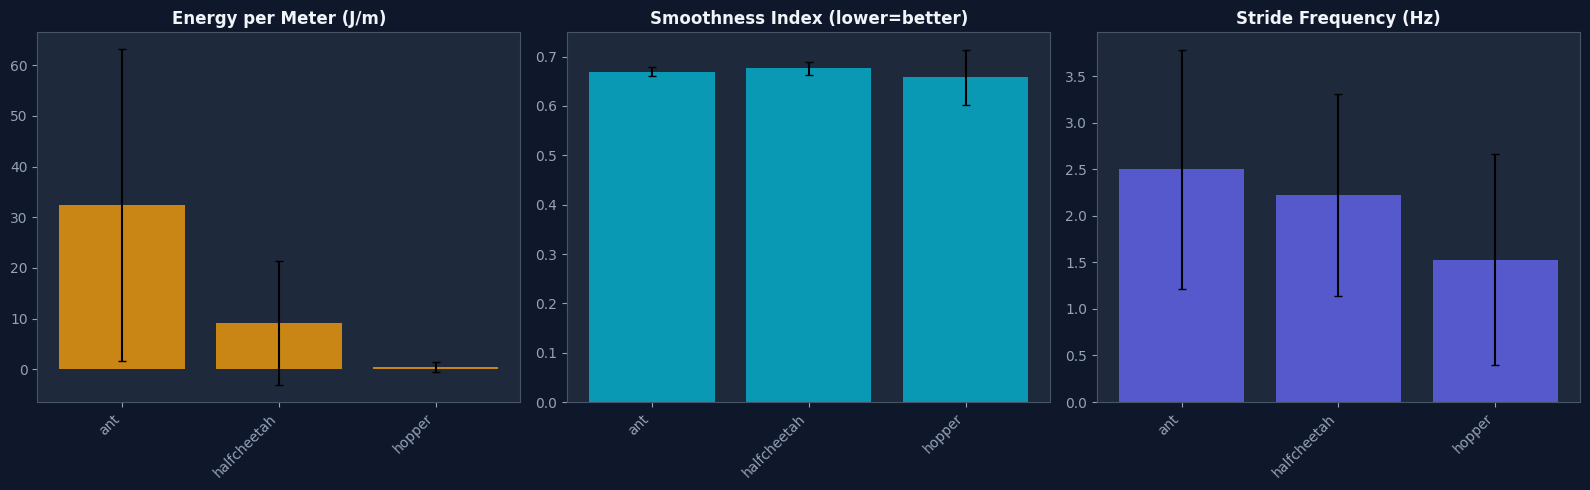

In [11]:
from olsd.sdk.visualization import plot_metrics_comparison
plot_metrics_comparison(all_eps, group_by="robot_id", show=True)

## Summary

This notebook demonstrated the full OLSD workflow:
- **Generate** trajectories with MuJoCo
- **Validate** data integrity
- **Compute** gait metrics (stride frequency, energy, smoothness)
- **Export/Load** in Parquet format
- **Filter/Split** for ML pipelines
- **Visualize** trajectories, phase portraits, and cross-robot comparisons

For CLI usage, see the README. For benchmark training, use `olsd train`.